In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa
import soundfile as sf
from tqdm import tqdm
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# preparation

In [2]:
path = "dataset"

## func

In [3]:
MAX_DURATION = 12

def extract_features(audio_path):
    y, sr = librosa.load(audio_path, sr=None, duration=MAX_DURATION)

    mels = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=20)
    mels_db = librosa.power_to_db(mels, ref=np.max)

    zcr = librosa.feature.zero_crossing_rate(y)

    return np.hstack([
        np.mean(mels_db, axis=1),
        np.std(mels_db, axis=1),
        np.mean(zcr, axis=1),
        np.std(zcr, axis=1)
    ])

In [4]:
SEGMENT_DURATION = 12
MIN_LONG_AUDIO = 60

def split_long_audio_files(source_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    class_dirs = [
        d for d in os.listdir(source_dir)
        if os.path.isdir(os.path.join(source_dir, d))
    ]

    for class_label in tqdm(class_dirs, desc="Splitting long audio"):
        source_class_path = os.path.join(source_dir, class_label)
        output_class_path = os.path.join(output_dir, class_label)
        os.makedirs(output_class_path, exist_ok=True)

        files = [
            f for f in os.listdir(source_class_path)
            if f.lower().endswith(('.wav', '.mp3'))
        ]

        for file in files:
            file_path = os.path.join(source_class_path, file)

            try:
                y, sr = librosa.load(file_path, sr=None)
                duration = librosa.get_duration(y=y, sr=sr)

                base_name = file.rsplit('.', 1)[0]

                if duration <= MIN_LONG_AUDIO:
                    save_path = os.path.join(output_class_path, f"{base_name}.wav")
                    if not os.path.exists(save_path):
                        sf.write(save_path, y, sr)
                    continue

                segment_samples = SEGMENT_DURATION * sr

                for i, start in enumerate(range(0, len(y), segment_samples)):
                    segment = y[start:start + segment_samples]

                    if len(segment) < sr:
                        continue

                    save_path = os.path.join(
                        output_class_path,
                        f"{base_name}_part_{i + 1}.wav"
                    )

                    sf.write(save_path, segment, sr)

            except Exception as e:
                print(f"Помилка під час обробки {file_path}: {e}")

In [5]:
def process_emotion_folders(audio_path):
    X, y = [], []
    
    emotion_dirs = [d for d in os.listdir(audio_path) if os.path.isdir(os.path.join(audio_path, d))]

    for emotion_label in tqdm(emotion_dirs, desc="Processing sounds"):
        emotion_path = os.path.join(audio_path, emotion_label)
        
        files = [f for f in os.listdir(emotion_path) if f.lower().endswith(('.wav', '.mp3'))]
        
        for file in files:
            file_path = os.path.join(emotion_path, file)
            
            features = extract_features(file_path)
            if features is not None:
                X.append(features)
                y.append(emotion_label)
                
    return np.array(X), np.array(y)

In [6]:
def convert_audio_to_images(source_dir, target_dir, n_mels=20):

    os.makedirs(target_dir, exist_ok=True)
    emotion_dirs = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

    for emotion_label in tqdm(emotion_dirs, desc="processing emotions"):
        source_emotion_path = os.path.join(source_dir, emotion_label)
        
        target_emotion_path = os.path.join(target_dir, emotion_label)
        os.makedirs(target_emotion_path, exist_ok=True)
        
        files = [f for f in os.listdir(source_emotion_path) if f.lower().endswith(('.wav', '.mp3'))]
    
        for file in files:
            file_path = os.path.join(source_emotion_path, file)
            new_file_name = file.rsplit('.', 1)[0] + '.png'
            save_path = os.path.join(target_emotion_path, new_file_name)
            
            y, sr = librosa.load(file_path, sr=22050)
                
            S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
            S_dB = librosa.power_to_db(S, ref=np.max)

            fig, ax = plt.subplots(figsize=(2, 2))
            ax.axis('off')
            fig.subplots_adjust(left=0, right=1, bottom=0, top=1) 

            librosa.display.specshow(S_dB, sr=sr, cmap='inferno', ax=ax)

            fig.savefig(save_path, format='png', dpi=100)
            plt.close(fig)

In [7]:
titles = ['без нормалізації', 'нормалізація по Recall', 'нормалізація по Precision']
def plot_cm(models, X, y_true):
    if not isinstance(models, (list, tuple)):
        models = [models]

    n_models = len(models)

    fig, axs = plt.subplots(n_models, 3, figsize=(20, 5 * n_models))

    if n_models == 1:
        axs = np.array([axs])

    for i, model in enumerate(models):
        y_pred = model.predict(X)
        cm = confusion_matrix(y_true, y_pred)
        cm_recall = confusion_matrix(
            y_true,
            y_pred,
            normalize='true'
        )
        cm_precision = confusion_matrix(
            y_true,
            y_pred,
            normalize='pred'
        )

        matrices = [cm, cm_recall, cm_precision]

        for j, matrix in enumerate(matrices):
            sns.heatmap(
                matrix,
                annot=True,
                fmt=['d', '.2f', '.2f'][j],
                cmap=['Greys', 'Greens', 'Purples'][j],
                ax=axs[i, j]
            )

            axs[i, j].set_title(titles[j])

            axs[i, j].set_xlabel('predicted label')
            axs[i, j].set_ylabel('true label')
            axs[i, j].tick_params(axis='y', labelrotation=0)

    plt.show()

## eda

In [24]:
audio_data = []
for class_name in os.listdir(path):
    folder = os.path.join(path, class_name)
    for file_name in os.listdir(folder):
        if file_name.endswith(".mp3"):
            audio_data.append([class_name, file_name, os.path.join(folder, file_name)])
df_audio = pd.DataFrame(
    audio_data,
    columns=["class", "file_name", "file_path"]
)
df_audio.head()

,class,file_name,file_path
0,air vehicles,Aircraft_-_Auster_aircraft__Landing_.mp3,dataset\air vehicles\Aircraft_-_Auster_aircraf...
1,air vehicles,Aircraft_-_Auster_aircraft__Landing__hits_soft...,dataset\air vehicles\Aircraft_-_Auster_aircraf...
2,air vehicles,Aircraft_-_Auster_aircraft__Passes_overhead.mp3,dataset\air vehicles\Aircraft_-_Auster_aircraf...
3,air vehicles,Aircraft_-_Auster_aircraft__Passes_overhead_.mp3,dataset\air vehicles\Aircraft_-_Auster_aircraf...
4,air vehicles,Aircraft_-_A_single_jet_707B_aircraft_passing_...,dataset\air vehicles\Aircraft_-_A_single_jet_7...


In [25]:
df_audio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284 entries, 0 to 283
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   class      284 non-null    object
 1   file_name  284 non-null    object
 2   file_path  284 non-null    object
dtypes: object(3)
memory usage: 6.8+ KB


In [26]:
df_audio.shape

(284, 3)

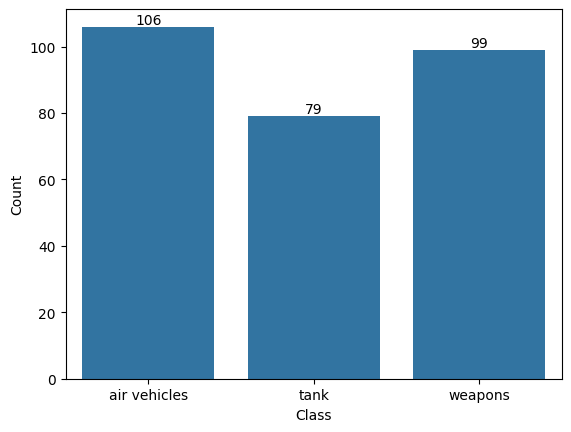

In [27]:
ax = sns.countplot(data=df_audio, x="class")

for container in ax.containers:
    ax.bar_label(container)

plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [28]:
# тривалість кожного аудіофайлу у нову колонку
durations = []
for file_path in df_audio["file_path"]:
    y, sr = librosa.load(file_path,
                         sr=None # залишити оригінальну частоту аудіо
                         )
    duration = librosa.get_duration(y=y, # аудіосигнал (масив чисел)
                                    sr=sr # sample rate (частота)
                                    )
    durations.append(duration)
df_audio["duration"] = durations

In [30]:
df_audio.groupby("class")["duration"].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
air vehicles,106.0,109.640474,95.370149,10.240000,40.373776,76.059773,143.151531,393.795147
tank,79.0,110.078606,103.381699,7.367596,37.070000,70.959637,154.826667,480.762268
weapons,99.0,63.888234,64.225453,2.566667,12.810057,41.200000,105.845590,339.057143


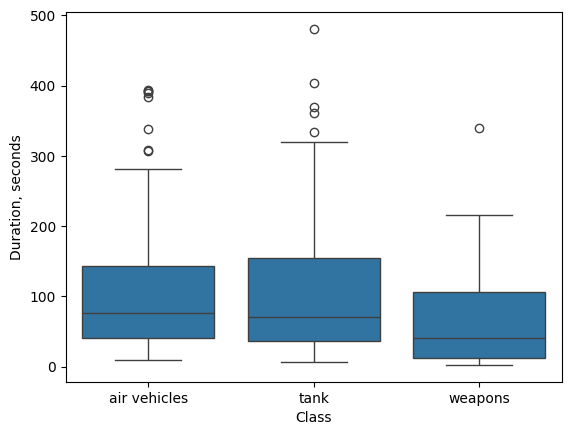

In [31]:
sns.boxplot(data=df_audio, x="class", y="duration")
plt.xlabel("Class")
plt.ylabel("Duration, seconds")
plt.show()

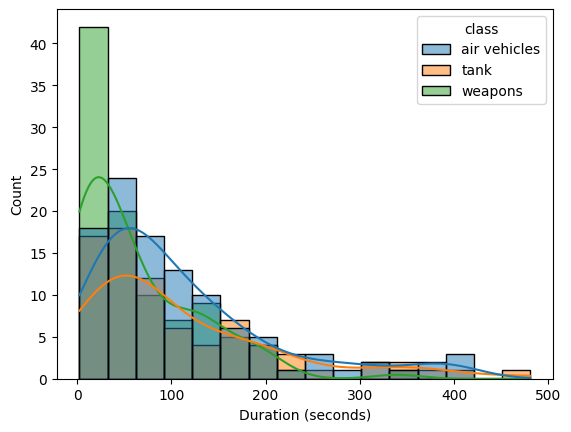

In [32]:
sns.histplot(data=df_audio, x="duration", hue="class", kde=True)
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()

In [34]:
print(df_audio.columns)

Index(['class', 'file_name', 'file_path', 'duration'], dtype='object')


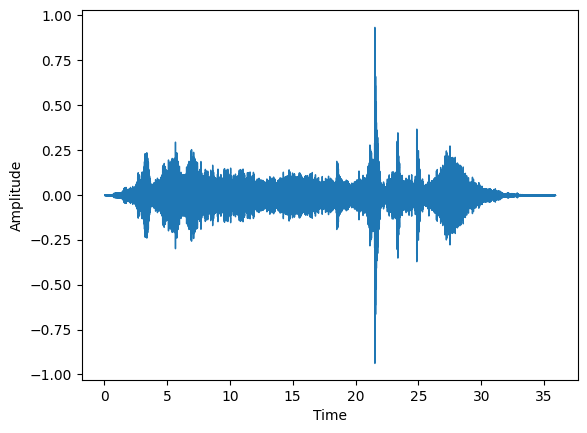

In [36]:
y, sr = librosa.load(df_audio["file_path"].iloc[0], sr=None)
librosa.display.waveshow(y, sr=sr)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

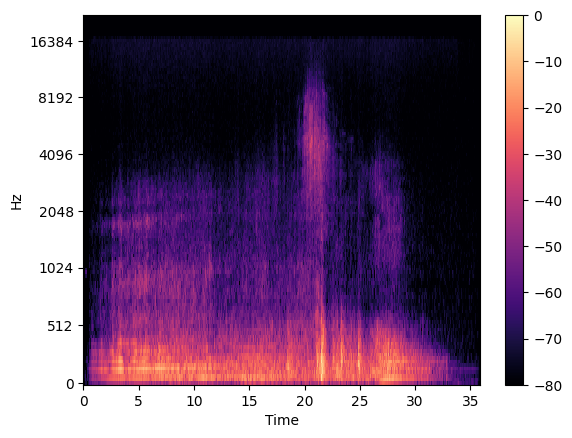

In [37]:
mel = librosa.feature.melspectrogram(y=y, sr=sr)
mel_db = librosa.power_to_db(mel, ref=np.max)
librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar()
plt.show()

## preprocess

In [9]:
path = "dataset"

split_long_audio_files(
    source_dir=path,
    output_dir="dataset_processed"
)

path = "dataset_processed"

Splitting long audio:   0%|          | 0/3 [00:00<?, ?it/s]d:\Downloads\anaconda\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
d:\Downloads\anaconda\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,
Splitting long audio: 100%|██████████| 3/3 [01:13<00:00, 24.56s/it]


In [10]:
output_folder = "spectrograms" 
convert_audio_to_images(path, output_folder)

processing emotions: 100%|██████████| 3/3 [02:29<00:00, 49.72s/it]


In [11]:
X_raw, y_raw = process_emotion_folders(path)

Processing sounds: 100%|██████████| 3/3 [02:34<00:00, 51.56s/it]


In [12]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=90, stratify=y_raw)

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

In [14]:
X_train_df = pd.DataFrame(X_train)
y_train_df = pd.DataFrame(y_train)
X_test_df = pd.DataFrame(X_test)
y_test_df = pd.DataFrame(y_test)

In [15]:
feature_names = ([f'mel_mean_{i}' for i in range(20)] + 
                 [f'mel_std_{i}' for i in range(20)] + 
                 ['zcr_mean', 'zcr_std'])

X_train_df.columns = feature_names

In [16]:
X_test_df.columns = X_train_df.columns

## vector eda

In [17]:
X_train_df.head()

,mel_mean_0,mel_mean_1,mel_mean_2,mel_mean_3,mel_mean_4,mel_mean_5,mel_mean_6,mel_mean_7,mel_mean_8,mel_mean_9,...,mel_std_12,mel_std_13,mel_std_14,mel_std_15,mel_std_16,mel_std_17,mel_std_18,mel_std_19,zcr_mean,zcr_std
0,0.189513,1.219052,1.362736,1.473780,1.575007,1.541335,1.616844,1.539902,1.376981,1.133900,...,-0.528098,-0.499208,-0.492790,-0.445881,-0.507632,-0.455621,-0.314215,-0.206791,-0.062278,-0.326575
1,0.564231,0.732278,0.799382,0.780951,0.914938,0.870043,0.791326,0.691158,0.542356,0.408544,...,-0.330193,-0.599962,-0.821651,-0.834842,-0.716022,-0.441294,-0.474299,-0.182789,-0.318024,-0.377458
2,0.860933,0.823397,1.098665,1.018807,0.660048,0.841744,0.546489,0.384105,0.286727,0.275080,...,-0.600543,-0.496152,-0.335203,-0.111918,0.152043,0.450303,0.987217,-0.394698,-0.422105,-0.449769
3,-0.672674,0.190116,0.371647,0.573906,0.898043,0.971070,0.830806,0.798124,0.853493,0.863617,...,2.067944,1.995927,1.976669,1.938989,1.576005,0.646952,0.015564,-0.620561,0.110619,-0.265474
4,0.638195,1.025106,1.031596,1.012340,1.185988,1.200016,1.426323,1.458571,1.474328,1.594061,...,-0.090829,-0.025526,0.094202,0.189965,0.105337,-0.535889,-0.456757,-0.143037,0.122937,-0.216774


In [18]:
X_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 42 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   mel_mean_0   1671 non-null   float64
 1   mel_mean_1   1671 non-null   float64
 2   mel_mean_2   1671 non-null   float64
 3   mel_mean_3   1671 non-null   float64
 4   mel_mean_4   1671 non-null   float64
 5   mel_mean_5   1671 non-null   float64
 6   mel_mean_6   1671 non-null   float64
 7   mel_mean_7   1671 non-null   float64
 8   mel_mean_8   1671 non-null   float64
 9   mel_mean_9   1671 non-null   float64
 10  mel_mean_10  1671 non-null   float64
 11  mel_mean_11  1671 non-null   float64
 12  mel_mean_12  1671 non-null   float64
 13  mel_mean_13  1671 non-null   float64
 14  mel_mean_14  1671 non-null   float64
 15  mel_mean_15  1671 non-null   float64
 16  mel_mean_16  1671 non-null   float64
 17  mel_mean_17  1671 non-null   float64
 18  mel_mean_18  1671 non-null   float64
 19  mel_mean_19  1671

# model training

## log regression

## svm

### OneVSOne

In [19]:
ovo = OneVsOneClassifier(SVC(class_weight='balanced', random_state=90))

param_random_ovo = {
    "estimator__C": [0.1, 1, 10],
    "estimator__kernel": ['linear', 'rbf', 'poly'],
    "estimator__gamma": ['scale', 'auto']
}

In [20]:
random_ovo = RandomizedSearchCV(ovo, param_random_ovo, cv=10, random_state=90, n_jobs=-1, scoring='f1_macro')
random_ovo.fit(X_train, y_train)
print("best OvO params:", random_ovo.best_params_)

best OvO params: {'estimator__kernel': 'rbf', 'estimator__gamma': 'auto', 'estimator__C': 10}


In [21]:
best_ovo = random_ovo.best_estimator_

In [22]:
y_pred_ovo = best_ovo.predict(X_test)

In [23]:
print(classification_report(y_test, y_pred_ovo))

              precision    recall  f1-score   support

air vehicles       0.91      0.86      0.89       185
        tank       0.85      0.90      0.88       136
     weapons       0.83      0.86      0.84        97

    accuracy                           0.87       418
   macro avg       0.87      0.87      0.87       418
weighted avg       0.87      0.87      0.87       418



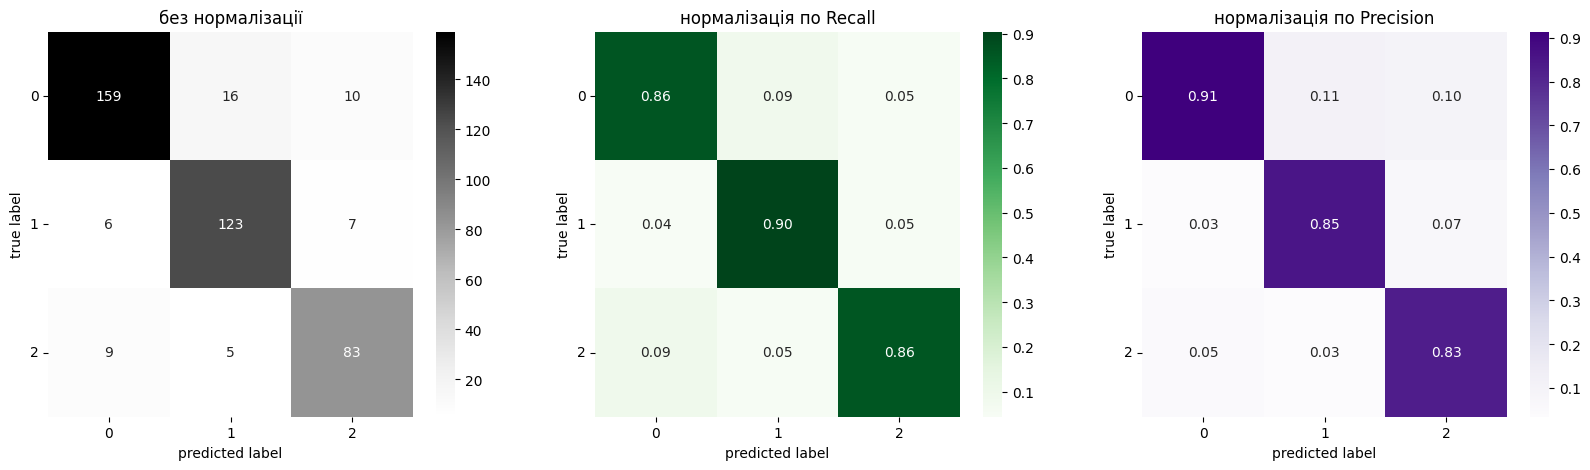

In [37]:
plot_cm(random_ovo.best_estimator_, X_test, y_test)

### OneVsRest

In [24]:
ovr = OneVsRestClassifier(SVC(class_weight='balanced', random_state=90))

param_random_ovr = {
    "estimator__C": [0.1, 1, 10],
    "estimator__kernel": ['linear', 'rbf', 'poly'],
    "estimator__gamma": ['scale', 'auto']
}

In [25]:
random_ovr = RandomizedSearchCV(ovr, param_random_ovr, cv=10, random_state=90, n_jobs=-1, scoring='f1_macro')
random_ovr.fit(X_train, y_train)
print("best OvR params:", random_ovr.best_params_)

best OvR params: {'estimator__kernel': 'rbf', 'estimator__gamma': 'scale', 'estimator__C': 10}


In [26]:
best_ovr = random_ovr.best_estimator_

In [27]:
y_pred_ovr = best_ovr.predict(X_test)

In [28]:
print(classification_report(y_test, y_pred_ovr))

              precision    recall  f1-score   support

air vehicles       0.91      0.88      0.89       185
        tank       0.87      0.90      0.89       136
     weapons       0.84      0.85      0.84        97

    accuracy                           0.88       418
   macro avg       0.87      0.88      0.87       418
weighted avg       0.88      0.88      0.88       418



In [29]:
print(classification_report(y_train, best_ovr.predict(X_train)))

              precision    recall  f1-score   support

air vehicles       0.95      0.94      0.94       738
        tank       0.95      0.93      0.94       542
     weapons       0.89      0.93      0.91       391

    accuracy                           0.93      1671
   macro avg       0.93      0.93      0.93      1671
weighted avg       0.93      0.93      0.93      1671



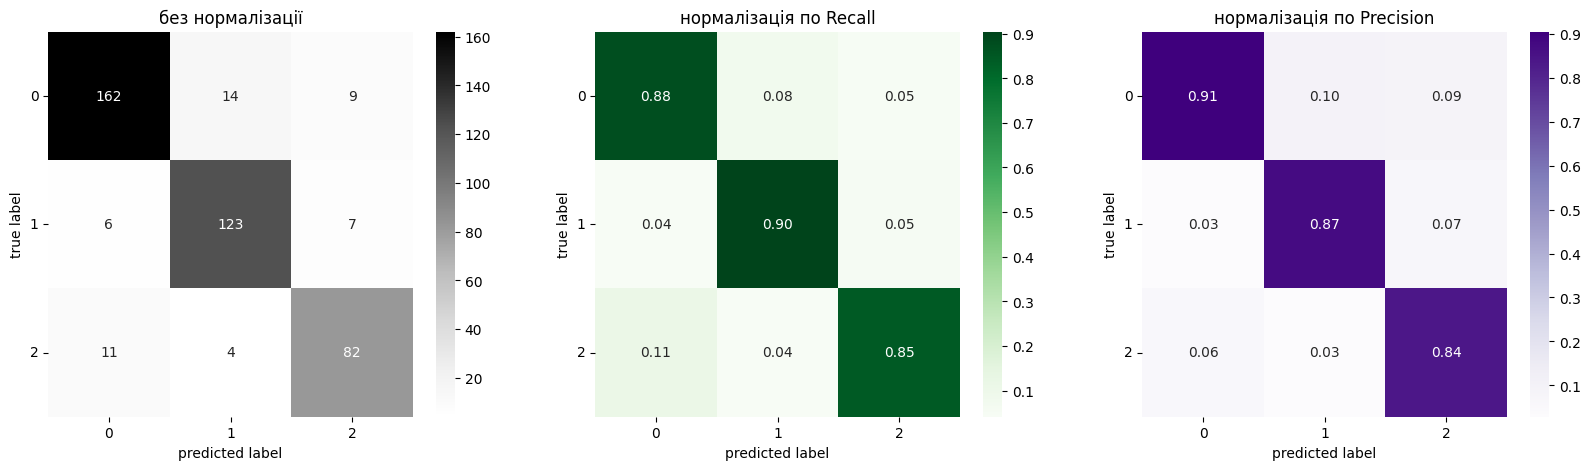

In [38]:
plot_cm(random_ovr.best_estimator_, X_test, y_test)

## boosting

In [30]:
boosting_model = GradientBoostingClassifier(random_state=90)

boosting_model.fit(X_train, y_train)

y_pred_boosting = boosting_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_boosting))
print(classification_report(y_test, y_pred_boosting))

Gradient Boosting Accuracy: 0.84688995215311
              precision    recall  f1-score   support

air vehicles       0.86      0.89      0.88       185
        tank       0.85      0.85      0.85       136
     weapons       0.81      0.76      0.79        97

    accuracy                           0.85       418
   macro avg       0.84      0.83      0.84       418
weighted avg       0.85      0.85      0.85       418



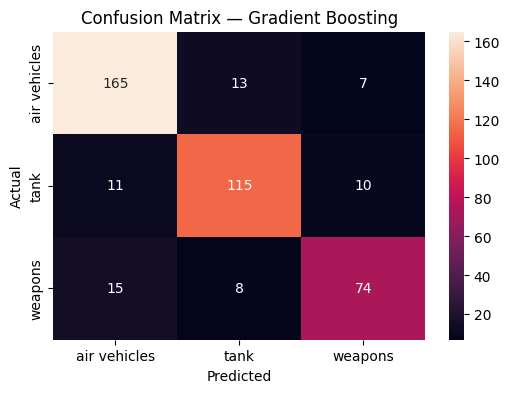

In [31]:
cm = confusion_matrix(y_test, y_pred_boosting)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=boosting_model.classes_,
    yticklabels=boosting_model.classes_
)

plt.title("Confusion Matrix — Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
param_dist = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

boosting_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=90),
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_macro",
    cv=3,
    random_state=90,
    n_jobs=-1
)

boosting_search.fit(X_train, y_train)

print("Best parameters:", boosting_search.best_params_)
print("Best CV score:", boosting_search.best_score_)

KeyboardInterrupt: 

In [ ]:
best_boosting_model = boosting_search.best_estimator_

y_pred_best_boosting = best_boosting_model.predict(X_test)

print("Tuned Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_best_boosting))
print(classification_report(y_test, y_pred_best_boosting))

Tuned Gradient Boosting Accuracy: 0.8803827751196173
              precision    recall  f1-score   support

air vehicles       0.88      0.91      0.90       185
        tank       0.91      0.88      0.90       136
     weapons       0.84      0.81      0.83        97

    accuracy                           0.88       418
   macro avg       0.88      0.87      0.87       418
weighted avg       0.88      0.88      0.88       418



In [ ]:
results_boosting = pd.DataFrame({
    "Model": ["Baseline Gradient Boosting", "Tuned Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_boosting),
        accuracy_score(y_test, y_pred_best_boosting)
    ],
    "F1 macro": [
        classification_report(y_test, y_pred_boosting, output_dict=True)["macro avg"]["f1-score"],
        classification_report(y_test, y_pred_best_boosting, output_dict=True)["macro avg"]["f1-score"]
    ]
})

results_boosting

,Model,Accuracy,F1 macro
0,Baseline Gradient Boosting,0.846890,0.836827
1,Tuned Gradient Boosting,0.880383,0.873100


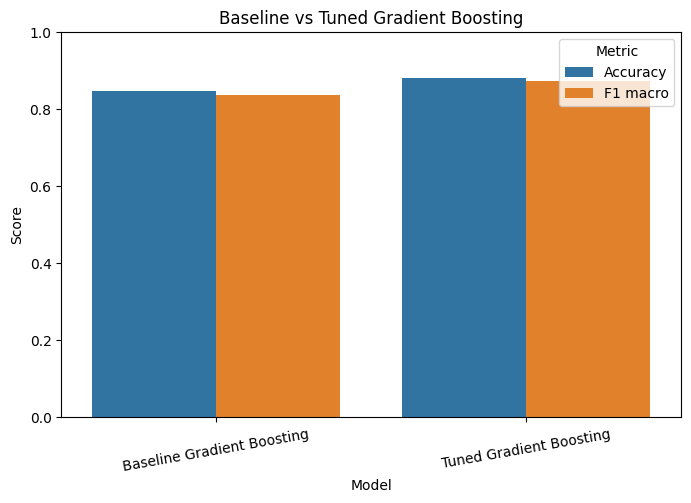

In [ ]:
results_boosting_melted = results_boosting.melt(
    id_vars="Model",
    value_vars=["Accuracy", "F1 macro"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=results_boosting_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Baseline vs Tuned Gradient Boosting")
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=10)
plt.show()

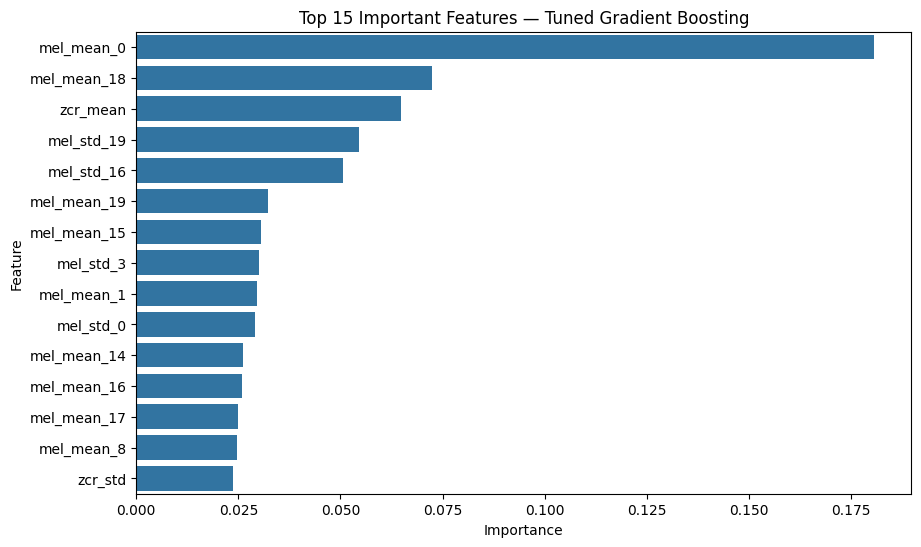

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_boosting_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features — Tuned Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
report_dict = classification_report(
    y_test,
    y_pred_best_boosting,
    output_dict=True
)

class_metrics = pd.DataFrame(report_dict).T
class_metrics = class_metrics.loc[
    [label for label in best_boosting_model.classes_],
    ["precision", "recall", "f1-score"]
]

class_metrics

,precision,recall,f1-score
air vehicles,0.880208,0.913514,0.896552
tank,0.909091,0.882353,0.895522
weapons,0.840426,0.814433,0.827225


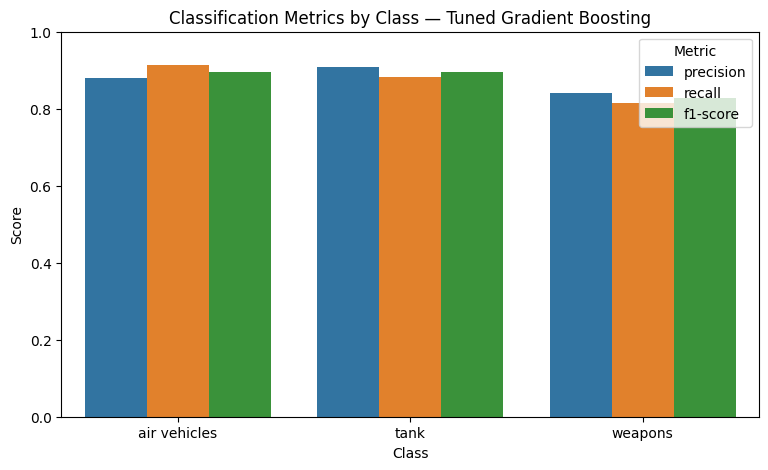

In [ ]:
class_metrics_melted = class_metrics.reset_index().melt(
    id_vars="index",
    value_vars=["precision", "recall", "f1-score"],
    var_name="Metric",
    value_name="Score"
)

class_metrics_melted = class_metrics_melted.rename(columns={"index": "Class"})

plt.figure(figsize=(9, 5))
sns.barplot(
    data=class_metrics_melted,
    x="Class",
    y="Score",
    hue="Metric"
)

plt.title("Classification Metrics by Class — Tuned Gradient Boosting")
plt.ylim(0, 1)
plt.xlabel("Class")
plt.ylabel("Score")
plt.show()

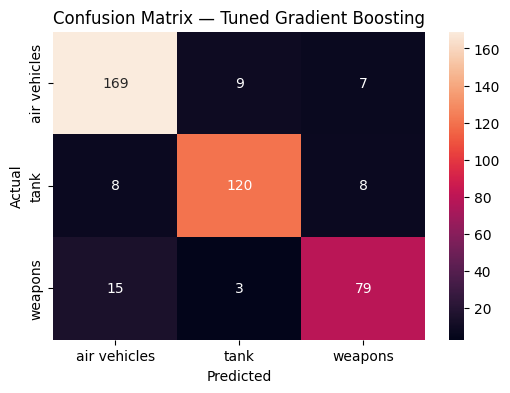

In [ ]:
cm = confusion_matrix(y_test, y_pred_best_boosting)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=best_boosting_model.classes_,
    yticklabels=best_boosting_model.classes_
)

plt.title("Confusion Matrix — Tuned Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()